In [71]:
import pandas as pd

train = pd.read_csv("../data/raw/Train-1542865627584.csv")
beneficiary = pd.read_csv("../data/raw/Train_Beneficiarydata-1542865627584.csv")
inpatient = pd.read_csv("../data/raw/Train_Inpatientdata-1542865627584.csv")
outpatient = pd.read_csv("../data/raw/Train_Outpatientdata-1542865627584.csv")

print("Train shape:", train.shape)
print("Beneficiary shape:", beneficiary.shape)
print("Inpatient shape:", inpatient.shape)
print("Outpatient shape:", outpatient.shape)


Train shape: (5410, 2)
Beneficiary shape: (138556, 25)
Inpatient shape: (40474, 30)
Outpatient shape: (517737, 27)


In [72]:
print("Train columns:", train.columns)
print("Inpatient columns:", inpatient.columns)
print("Outpatient columns:", outpatient.columns)
print("Beneficiary columns:", beneficiary.columns)


Train columns: Index(['Provider', 'PotentialFraud'], dtype='object')
Inpatient columns: Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'AdmissionDt', 'ClmAdmitDiagnosisCode',
       'DeductibleAmtPaid', 'DischargeDt', 'DiagnosisGroupCode',
       'ClmDiagnosisCode_1', 'ClmDiagnosisCode_2', 'ClmDiagnosisCode_3',
       'ClmDiagnosisCode_4', 'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6',
       'ClmDiagnosisCode_7', 'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9',
       'ClmDiagnosisCode_10', 'ClmProcedureCode_1', 'ClmProcedureCode_2',
       'ClmProcedureCode_3', 'ClmProcedureCode_4', 'ClmProcedureCode_5',
       'ClmProcedureCode_6'],
      dtype='object')
Outpatient columns: Index(['BeneID', 'ClaimID', 'ClaimStartDt', 'ClaimEndDt', 'Provider',
       'InscClaimAmtReimbursed', 'AttendingPhysician', 'OperatingPhysician',
       'OtherPhysician', 'ClmDiagnosisCode_1', 'Cl

In [73]:
train['PotentialFraud'].value_counts()
train['PotentialFraud'].value_counts(normalize=True)


PotentialFraud
No     0.90647
Yes    0.09353
Name: proportion, dtype: float64

In [74]:
inpatient_agg = inpatient.groupby("Provider").agg({
    "ClaimID": "count",
    "InscClaimAmtReimbursed": "mean",
    "BeneID": pd.Series.nunique
}).reset_index()

inpatient_agg.columns = [
    "Provider",
    "total_inpatient_claims",
    "avg_inpatient_claim_amount",
    "unique_inpatient_patients"
]


In [75]:
outpatient_agg = outpatient.groupby("Provider").agg({
    "ClaimID": "count",
    "InscClaimAmtReimbursed": "mean",
    "BeneID": pd.Series.nunique
}).reset_index()

outpatient_agg.columns = [
    "Provider",
    "total_outpatient_claims",
    "avg_outpatient_claim_amount",
    "unique_outpatient_patients"
]


In [76]:
provider_claims = inpatient_agg.merge(
    outpatient_agg,
    on="Provider",
    how="outer"
)


In [77]:
provider_claims.isnull().sum()


Provider                          0
total_inpatient_claims         3318
avg_inpatient_claim_amount     3318
unique_inpatient_patients      3318
total_outpatient_claims         398
avg_outpatient_claim_amount     398
unique_outpatient_patients      398
dtype: int64

In [78]:
provider_claims.fillna(0, inplace=True)


In [79]:
provider_claims.isnull().sum()


Provider                       0
total_inpatient_claims         0
avg_inpatient_claim_amount     0
unique_inpatient_patients      0
total_outpatient_claims        0
avg_outpatient_claim_amount    0
unique_outpatient_patients     0
dtype: int64

In [80]:
provider_data = train.merge(
    provider_claims,
    on="Provider",
    how="left"
)


In [81]:
provider_data.shape
provider_data.head()


,Provider,PotentialFraud,total_inpatient_claims,avg_inpatient_claim_amount,unique_inpatient_patients,total_outpatient_claims,avg_outpatient_claim_amount,unique_outpatient_patients
0,PRV51001,No,5.0,19400.000000,5.0,20.0,382.000000,19.0
1,PRV51003,Yes,62.0,9241.935484,53.0,70.0,466.714286,66.0
2,PRV51004,No,0.0,0.000000,0.0,149.0,350.134228,138.0
3,PRV51005,Yes,0.0,0.000000,0.0,1165.0,241.124464,495.0
4,PRV51007,No,3.0,6333.333333,3.0,69.0,213.188406,56.0


In [82]:
provider_data["total_claims"] = (
    provider_data["total_inpatient_claims"] +
    provider_data["total_outpatient_claims"]
)


In [83]:
provider_data["inpatient_ratio"] = (
    provider_data["total_inpatient_claims"] /
    provider_data["total_claims"]
)


In [84]:
provider_data["inpatient_ratio"].fillna(0, inplace=True)


C:\Users\User\AppData\Local\Temp\ipykernel_15400\1809736185.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  provider_data["inpatient_ratio"].fillna(0, inplace=True)


In [85]:
provider_data["total_unique_patients"] = (
    provider_data["unique_inpatient_patients"] +
    provider_data["unique_outpatient_patients"]
)

provider_data["claims_per_patient"] = (
    provider_data["total_claims"] /
    provider_data["total_unique_patients"]
)

provider_data["claims_per_patient"].fillna(0, inplace=True)


C:\Users\User\AppData\Local\Temp\ipykernel_15400\3222102875.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  provider_data["claims_per_patient"].fillna(0, inplace=True)


In [86]:
provider_data["avg_claim_amount"] = (
    provider_data["avg_inpatient_claim_amount"] +
    provider_data["avg_outpatient_claim_amount"]
) / 2


In [87]:
import numpy as np 
provider_data["log_total_claims"] = np.log1p(provider_data["total_claims"])

In [88]:
provider_data["PotentialFraud"] = provider_data["PotentialFraud"].map({
    "Yes": 1,
    "No": 0
})


In [89]:
provider_data.shape
provider_data.head()


,Provider,PotentialFraud,total_inpatient_claims,avg_inpatient_claim_amount,unique_inpatient_patients,total_outpatient_claims,avg_outpatient_claim_amount,unique_outpatient_patients,total_claims,inpatient_ratio,total_unique_patients,claims_per_patient,avg_claim_amount,log_total_claims
0,PRV51001,0,5.0,19400.000000,5.0,20.0,382.000000,19.0,25.0,0.200000,24.0,1.041667,9891.000000,3.258097
1,PRV51003,1,62.0,9241.935484,53.0,70.0,466.714286,66.0,132.0,0.469697,119.0,1.109244,4854.324885,4.890349
2,PRV51004,0,0.0,0.000000,0.0,149.0,350.134228,138.0,149.0,0.000000,138.0,1.079710,175.067114,5.010635
3,PRV51005,1,0.0,0.000000,0.0,1165.0,241.124464,495.0,1165.0,0.000000,495.0,2.353535,120.562232,7.061334
4,PRV51007,0,3.0,6333.333333,3.0,69.0,213.188406,56.0,72.0,0.041667,59.0,1.220339,3273.260870,4.290459


In [90]:
X = provider_data.drop(columns=["Provider", "PotentialFraud"])
y = provider_data["PotentialFraud"]


In [91]:
X.head()


,total_inpatient_claims,avg_inpatient_claim_amount,unique_inpatient_patients,total_outpatient_claims,avg_outpatient_claim_amount,unique_outpatient_patients,total_claims,inpatient_ratio,total_unique_patients,claims_per_patient,avg_claim_amount,log_total_claims
0,5.0,19400.000000,5.0,20.0,382.000000,19.0,25.0,0.200000,24.0,1.041667,9891.000000,3.258097
1,62.0,9241.935484,53.0,70.0,466.714286,66.0,132.0,0.469697,119.0,1.109244,4854.324885,4.890349
2,0.0,0.000000,0.0,149.0,350.134228,138.0,149.0,0.000000,138.0,1.079710,175.067114,5.010635
3,0.0,0.000000,0.0,1165.0,241.124464,495.0,1165.0,0.000000,495.0,2.353535,120.562232,7.061334
4,3.0,6333.333333,3.0,69.0,213.188406,56.0,72.0,0.041667,59.0,1.220339,3273.260870,4.290459


In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [93]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)


c:\Users\User\OneDrive\Desktop\healthcare-claims-risk\venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [94]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_proba = log_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", roc_auc)
print(classification_report(y_test, log_model.predict(X_test)))


ROC-AUC: 0.9566213502084154
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       981
           1       0.84      0.57      0.68       101

    accuracy                           0.95      1082
   macro avg       0.90      0.78      0.83      1082
weighted avg       0.95      0.95      0.95      1082



In [95]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)


Random Forest ROC-AUC: 0.9595583411552164


In [96]:
print("Logistic Regression ROC-AUC:", roc_auc)
print("Random Forest ROC-AUC:", roc_auc_rf)


Logistic Regression ROC-AUC: 0.9566213502084154
Random Forest ROC-AUC: 0.9595583411552164


In [97]:
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)


In [98]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)


In [99]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)



,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_model.predict(X_test)))



[[962  19]
 [ 44  57]]


In [101]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf_model.predict(X_test)))


[[962  19]
 [ 44  57]]


In [102]:
rf_model.feature_importances_


array([0.165356  , 0.09426035, 0.13988571, 0.05304313, 0.04411858,
       0.0421897 , 0.07485371, 0.05660891, 0.06782608, 0.05703542,
       0.13654921, 0.06827318])

In [103]:
from sklearn.metrics import roc_auc_score

y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC:", roc_auc)


ROC-AUC: 0.9540174200906328


In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_model.predict(X_test)))


              precision    recall  f1-score   support

           0       0.96      0.98      0.97       981
           1       0.75      0.56      0.64       101

    accuracy                           0.94      1082
   macro avg       0.85      0.77      0.81      1082
weighted avg       0.94      0.94      0.94      1082



In [105]:
import numpy as np

y_pred_custom = (y_pred_proba > 0.4).astype(int)

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_custom))


[[951  30]
 [ 37  64]]


In [106]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)


total_inpatient_claims         0.165356
unique_inpatient_patients      0.139886
avg_claim_amount               0.136549
avg_inpatient_claim_amount     0.094260
total_claims                   0.074854
log_total_claims               0.068273
total_unique_patients          0.067826
claims_per_patient             0.057035
inpatient_ratio                0.056609
total_outpatient_claims        0.053043
avg_outpatient_claim_amount    0.044119
unique_outpatient_patients     0.042190
dtype: float64


 99%|===================| 2146/2164 [01:29<00:00]        

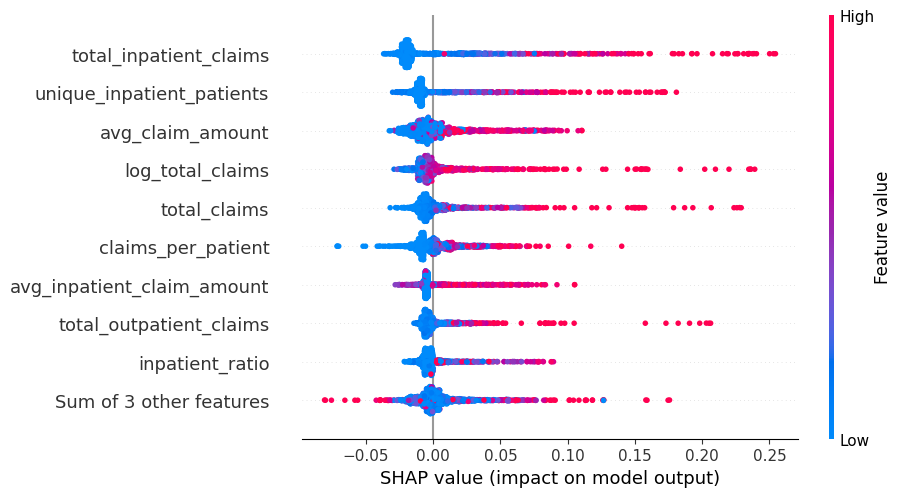

In [107]:
import shap

explainer = shap.Explainer(rf_model, X_train)
shap_values = explainer(X_test)

# Select class 1 (fraud class)
shap.plots.beeswarm(shap_values[:, :, 1])


In [108]:
import pandas as pd

mean_abs_shap = pd.DataFrame({
    "feature": X.columns,
    "importance": abs(shap_values[:, :, 1].values).mean(axis=0)
}).sort_values(by="importance", ascending=False)

print(mean_abs_shap.head(5))


                      feature  importance
0      total_inpatient_claims    0.032399
2   unique_inpatient_patients    0.018788
10           avg_claim_amount    0.015277
11           log_total_claims    0.014567
6                total_claims    0.014330


In [109]:
import os

os.makedirs("models", exist_ok=True)

import joblib
joblib.dump(rf_model, "models/claims_risk_model.pkl")


['models/claims_risk_model.pkl']

In [110]:
joblib.dump(list(X.columns), "models/feature_columns.pkl")


['models/feature_columns.pkl']

In [111]:
print(feature_columns)


['total_inpatient_claims', 'avg_inpatient_claim_amount', 'unique_inpatient_patients', 'total_outpatient_claims', 'avg_outpatient_claim_amount', 'unique_outpatient_patients', 'total_claims', 'inpatient_ratio', 'total_unique_patients', 'claims_per_patient', 'avg_claim_amount', 'log_total_claims']
